In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
# CRIANDO UM DATAFRAME A PARTIR DOS DADOS
from src.data_loading import load_data
from src.preprocessing import prepare_data_classifier

df = load_data('../data/processed/prepared_dataset.csv')
df_tratado = prepare_data_classifier(df)


In [21]:
#separando feature do target

X = df_tratado.drop(columns='categorias_target')
y = df_tratado['categorias_target'].copy()

### 3.1 Separando train_set do test_set

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=42,
                                                    stratify=df_tratado['categorias_target'])

In [23]:
#verificando se o stratify funcionou bem
print(y_train.value_counts(normalize=True).sort_index())
print(y_test.value_counts(normalize=True).sort_index())

categorias_target
até R$ 3.000/mês                    0.089240
de 3.001/mês a R$ 6.000/mês         0.181305
de R$ 6.001/mês a R$ 8.000/mês      0.136402
de R$ 8.001/mês a R$ 12.000/mês     0.225360
de R$ 12.001/mês a R$ 20.000/mês    0.241740
acima de R$ 20.000/mês              0.125953
Name: proportion, dtype: float64
categorias_target
até R$ 3.000/mês                    0.089754
de 3.001/mês a R$ 6.000/mês         0.181202
de R$ 6.001/mês a R$ 8.000/mês      0.136325
de R$ 8.001/mês a R$ 12.000/mês     0.225233
de R$ 12.001/mês a R$ 20.000/mês    0.241321
acima de R$ 20.000/mês              0.126164
Name: proportion, dtype: float64


In [24]:
X_train.columns

Index(['Unnamed: 0', 'idade', 'uf_onde_mora', 'nivel_de_ensino',
       'area_formacao', 'situacao_trabalho', 'setor', 'cargo_atual',
       'nivel_senioridade', 'tempo_experiencia', 'JS', 'Java', 'R', 'Python',
       'SQL', 'Oracle', 'MySQL', 'Google_BigQuery', 'SQL_Server', 'Databricks',
       'PostgreSQL', 'nao_utilizamos_cloud', 'Google_cloud', 'Azure', 'AWS'],
      dtype='str')

### 3.2 Gerando o Pipeline

In [25]:
#organizando as features pro type
num_list = ['idade']

cat_ordinal_list = ['nivel_de_ensino',
                    'nivel_senioridade',
                    'tempo_experiencia']

cat_one_hot_list = ['uf_onde_mora', 
                     'area_formacao', 'situacao_trabalho',
                     'setor', 'cargo_atual']

bin_list = ['JS', 'Java', 'R', 'Python',
       'SQL', 'Oracle', 'MySQL', 'Google_BigQuery', 'SQL_Server', 'Databricks',
       'PostgreSQL', 'nao_utilizamos_cloud', 'Google_cloud', 'Azure', 'AWS']

In [26]:
#montando o pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = make_pipeline(StandardScaler())

cat_ord_pipeline = make_pipeline(SimpleImputer(strategy='constant',
                                               fill_value='Nao Informado'),
                                 OrdinalEncoder(categories=[
                                        ['Prefiro não informar', 'Não tenho graduação formal',
                                        'Estudante de Graduação', 'Graduação/Bacharelado',
                                        'Pós-graduação', 'Mestrado', 'Doutorado ou Phd' ],
                                        ['Nao Informado', 'Júnior', 'Pleno', 'Sênior'],
                                        ['Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados',
                                        'Menos de 1 ano', 'de 1 a 2 anos','de 3 a 4 anos','de 5 a 6 anos','de 7 a 10 anos','Mais de 10 anos']]))
                                 

cat_one_hot_pipeline = make_pipeline(SimpleImputer(strategy='constant',
                                                   fill_value='Nao Informado'),
                                     OneHotEncoder(handle_unknown='ignore',
                                                   sparse_output=False))
                                     

bin_pipeline = make_pipeline(SimpleImputer(strategy='constant',
                                           fill_value=0))


### 3.3 Column Transform

In [27]:
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
   ('numeric', num_pipeline, num_list), 
   ('ordinal_encoded', cat_ord_pipeline, cat_ordinal_list), 
   ('one_hot_encoded', cat_one_hot_pipeline, cat_one_hot_list), 
   ('bin', bin_pipeline, bin_list) 
])


criando um x_train com preprocessamento

In [28]:
X_preprocessed = pd.DataFrame(preprocessing.fit_transform(X_train),
                columns=preprocessing.get_feature_names_out(),
                index=X_train.index)

### 3.4. Escolhendo o Modelo para Exportar

In [36]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

#o certo é passar o pipeline completo
baseline_model = make_pipeline(preprocessing, DummyClassifier(strategy='most_frequent'))
svc_model = make_pipeline(preprocessing, SVC(random_state=42))
rfc_model = make_pipeline(preprocessing, RandomForestClassifier(random_state=42))
lr_model = make_pipeline(preprocessing, LogisticRegression(random_state=42,
                                                           max_iter=1000)) 

models = [baseline_model, svc_model, rfc_model, lr_model]

for idx, model in enumerate(models):
    cvs = cross_val_score(model,
                    X_train,
                    y_train,
                    scoring='f1_macro',
                    cv=3)
    print(f'''O modelo {type(model.steps[-1][1]).__name__},
          teve MÉDIA DE ACERTOS de {cvs.mean():.1%}
          e DESVIO PADRÃO de {cvs.std():.4%}''')

O modelo DummyClassifier,
          teve MÉDIA DE ACERTOS de 6.5%
          e DESVIO PADRÃO de 0.0098%
O modelo SVC,
          teve MÉDIA DE ACERTOS de 47.9%
          e DESVIO PADRÃO de 0.7240%
O modelo RandomForestClassifier,
          teve MÉDIA DE ACERTOS de 48.9%
          e DESVIO PADRÃO de 0.7583%
O modelo LogisticRegression,
          teve MÉDIA DE ACERTOS de 48.8%
          e DESVIO PADRÃO de 0.6533%


_Ao analisar os resultados, o módelo provisório favorito é o LogisticRegressor com:_

MÉDIA DE ACERTOS de 49.2% e DESVIO PADRÃO de 0.0147

In [37]:
#adicionando class_weight para inverter o peso, ou seja, dados menos frequentes terão mais peso.
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

#o certo é passar o pipeline completo
baseline_model = make_pipeline(preprocessing, DummyClassifier(strategy='most_frequent'))
svc_model_bal = make_pipeline(preprocessing, SVC(random_state=42,
                                             class_weight='balanced'))
rfc_model_bal = make_pipeline(preprocessing, RandomForestClassifier(random_state=42,
                                                                class_weight='balanced'))
lr_model_bal = make_pipeline(preprocessing, LogisticRegression(random_state=42,
                                                           class_weight='balanced',
                                                           max_iter=1000)) 

models = [baseline_model, svc_model_bal, rfc_model_bal, lr_model_bal]

for idx, model in enumerate(models):
    cvs = cross_val_score(model,
                    X_train,
                    y_train,
                    scoring='f1_macro',
                    cv=3)
    print(f'''O modelo {type(model.steps[-1][1]).__name__},
          teve MÉDIA DE ACERTOS de {cvs.mean():.1%}
          e DESVIO PADRÃO de {cvs.std():.4%}''')

O modelo DummyClassifier,
          teve MÉDIA DE ACERTOS de 6.5%
          e DESVIO PADRÃO de 0.0098%
O modelo SVC,
          teve MÉDIA DE ACERTOS de 47.9%
          e DESVIO PADRÃO de 0.5581%
O modelo RandomForestClassifier,
          teve MÉDIA DE ACERTOS de 49.0%
          e DESVIO PADRÃO de 0.1828%
O modelo LogisticRegression,
          teve MÉDIA DE ACERTOS de 47.6%
          e DESVIO PADRÃO de 0.5193%


balanced ajudou modelos de árvore/margem, atrapalhou o linear

Por enquanto o modelo escolhido é o RandomForestClassifier com class_weight balanced

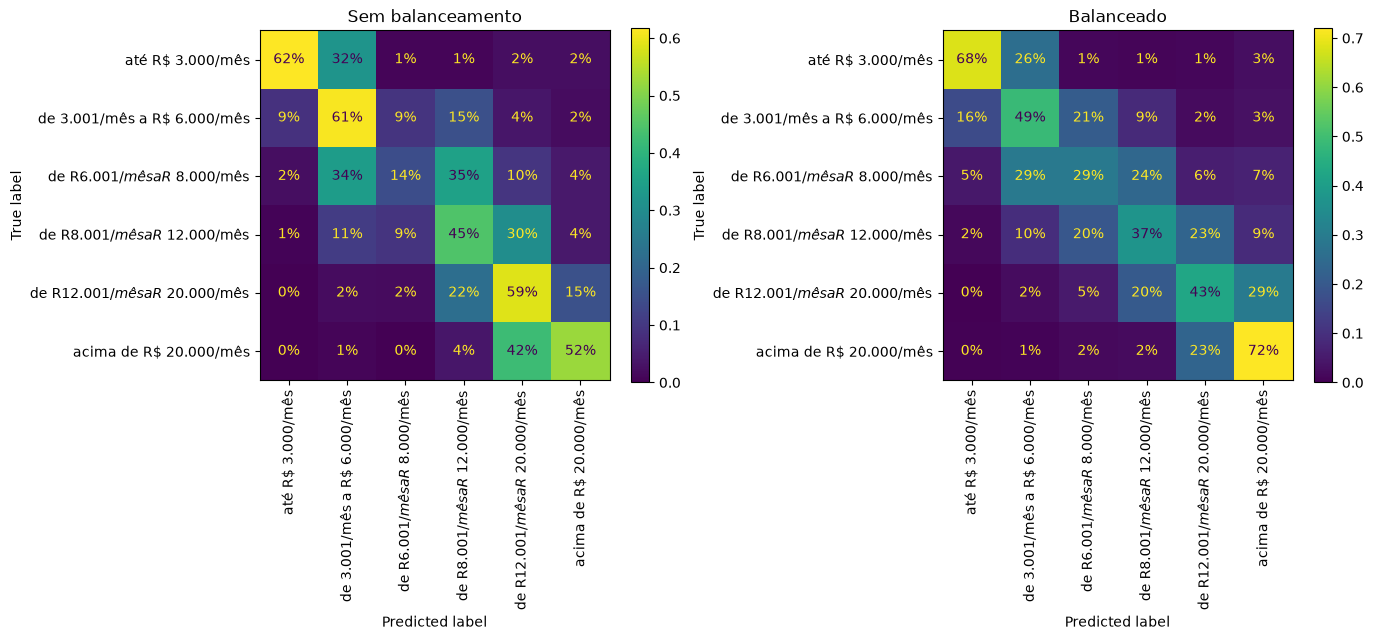

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

lr_bal_predicts = cross_val_predict(lr_model_bal,
                                 X_train,
                                 y_train,
                                 cv=3)

lr_predicts = cross_val_predict(lr_model,
                                 X_train,
                                 y_train,
                                 cv=3)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(y_train, lr_predicts,
                                        normalize='true',
                                        values_format='.0%',
                                        labels=list(y_train.cat.categories),
                                        xticks_rotation='vertical',
                                        ax=axs[0])
axs[0].set_title('Sem balanceamento')

ConfusionMatrixDisplay.from_predictions(y_train, lr_bal_predicts,
                                        normalize='true',
                                        values_format='.0%',
                                        labels=list(y_train.cat.categories),
                                        xticks_rotation='vertical',
                                        ax=axs[1])
axs[1].set_title('Balanceado')

plt.tight_layout()
plt.show()




### 3.5. Definindo Pipeline Final / Exportando modelo

In [39]:
from joblib import dump

#treinamento final do modelo escolhido
lr_model_bal.fit(X_train, y_train)

#exportando o modelo final
dump(lr_model_bal, '../models/lr_model_bal.joblib')

['../models/lr_model_bal.joblib']